# Final Breast Cancer Classification Model

This notebook contains the final refined machine learning pipeline for the SPC4004 Code Generation Project.

The aim is to classify tumours as malignant or benign using the scikit-learn Wisconsin Diagnostic Breast Cancer dataset. This version reflects the final model selection and evaluation after iterative improvements to the initial AI-generated code.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    recall_score
)

# 1. Load the dataset

The Wisconsin Diagnostic Breast Cancer dataset is loaded from scikit-learn.  
The dataset contains numerical features extracted from digitised images of breast mass cell nuclei.

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target names:", data.target_names)

Feature matrix shape: (569, 30)
Target vector shape: (569,)
Target names: ['malignant' 'benign']


## 2. Examine class distribution

Before training the model, the class distribution is checked to understand the balance between malignant and benign tumours.

Class counts: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


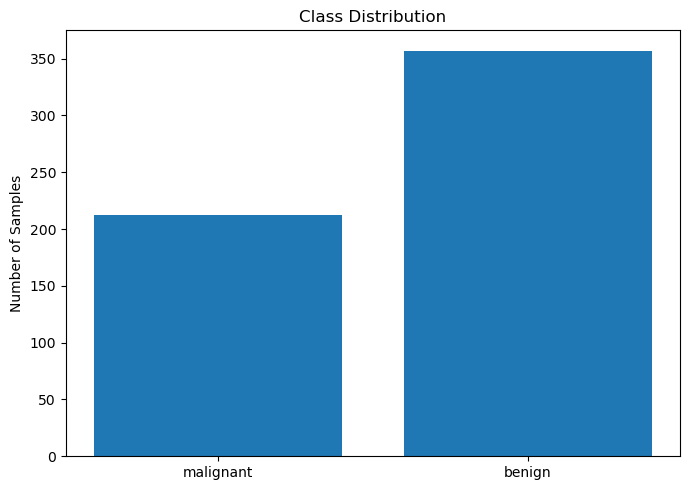

In [4]:
class_counts = np.bincount(y)
labels = data.target_names

print("Class counts:", dict(zip(labels, class_counts)))

plt.figure(figsize=(7, 5))
plt.bar(labels, class_counts)
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## 3. Split the data

The dataset is divided into training and testing sets using stratified sampling so that both sets preserve the original class proportions.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 30)
Test set shape: (114, 30)


## 4. Scale the features

StandardScaler is applied because the final chosen model performs better when features are on a comparable scale.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train the final model

Logistic Regression was selected as the final model because it achieved strong perform

In [12]:
final_model = LogisticRegression(max_iter=10000, random_state=42)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)

## 6. Evaluate the model

The final model is evaluated using accuracy, recall, a classification report, and a confusion matrix.

In [13]:
accuracy = accuracy_score(y_test, y_pred)
malignant_recall = recall_score(y_test, y_pred, pos_label=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall for malignant tumours: {malignant_recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy: 0.9737
Recall for malignant tumours: 0.9286

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7. Confusion matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

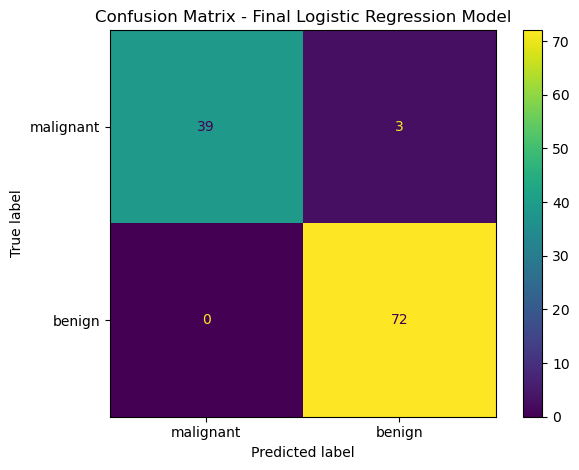

In [15]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.title("Confusion Matrix - Final Logistic Regression Model")
plt.tight_layout()
plt.show()

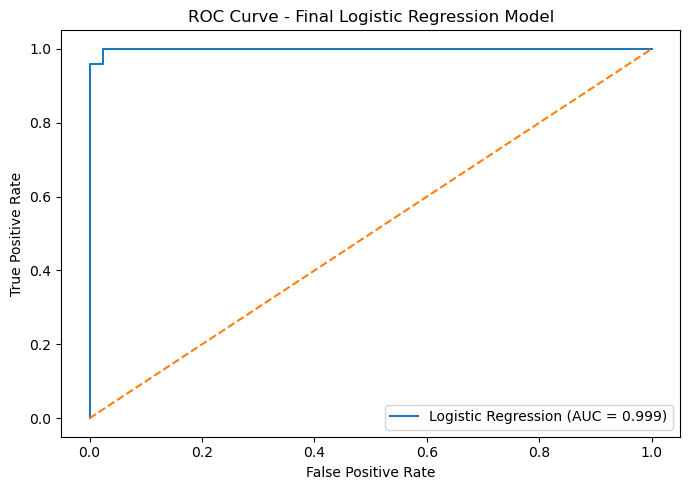

In [17]:
y_score = final_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Final Logistic Regression Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary

The final Logistic Regression model achieved strong classification performance on the breast cancer dataset. In addition to high overall accuracy, the model demonstrated strong recall for malignant tumours, which is particularly important in a medical classification context.

This final notebook represents the refined version of the model after improving the original AI-generated code through better data splitting, feature scaling, richer evaluation metrics, and comparison with alternative algorithms.